In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


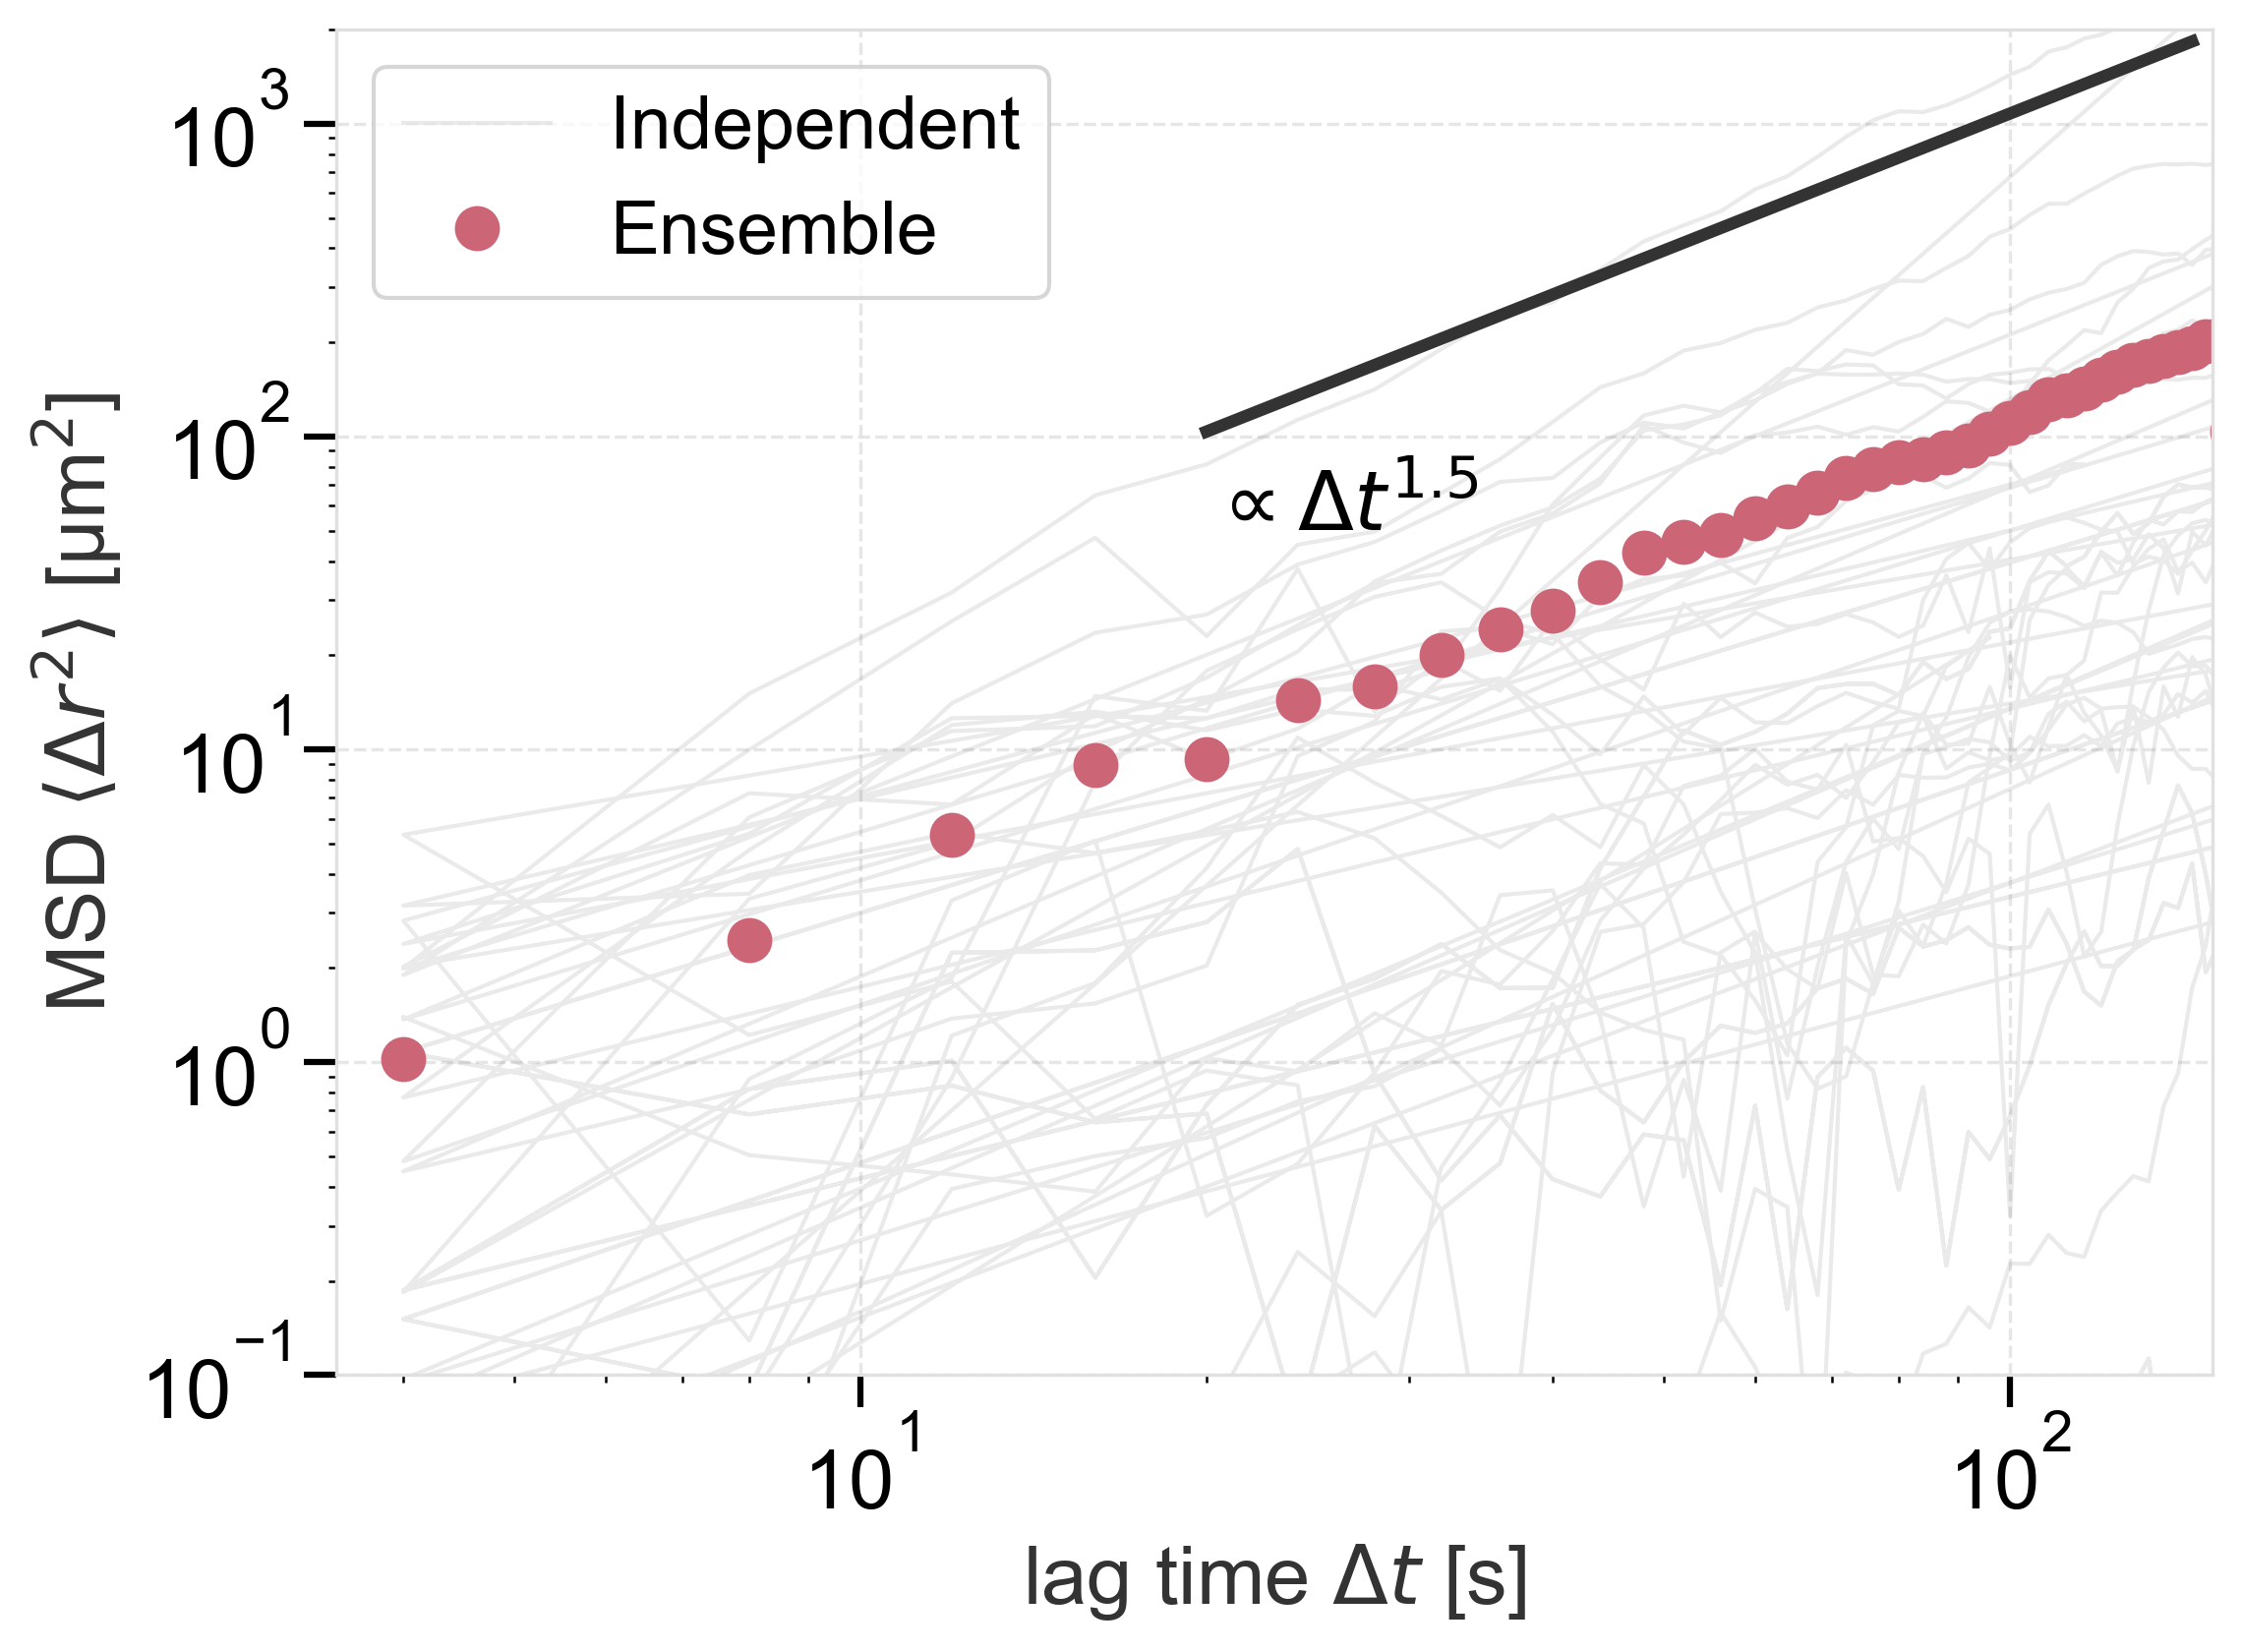

In [6]:
mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")


def concatMSD(path_list, interval_list, scale = 0.11, time_averaged = True):
    IMSD_list = []
    for i in range(len(path_list)):
        print(path_list[i])
        IMSD, _ = dpm.get_msd(path_list[i], scale, interval_list[i], threshold = 0.0, time_averaged=time_averaged)
        IMSD['particle'] += 10000*i
        IMSD_list.append(IMSD)

    return pd.concat(IMSD_list)

I_concat = concatMSD([path0, path1, path2, path4, path4], [ 4, 4, 4, 4, 4], time_averaged=False)

scale = 0.11

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined, emsd_err_combined = dpm.get_emsd_err(I_concat)

mask = (emsd_combined.index > minimum) & (emsd_combined.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined['MSD'][mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

ax.plot(I_concat['lag time'], I_concat['MSD'], color='#333333', alpha =0.1, lw=1, label='Independent')

#ax.plot(TA_emsd_combined.index, TA_emsd_combined['MSD'], linestyle = 'None', marker='o', label='Time Averaged', color = style_colors[0])
ax.plot(emsd_combined.index, emsd_combined['MSD'], linestyle = 'None', marker='o', label='Ensemble')

"""
ax.fill_between(emsd_combined.index,
                emsd_combined['MSD'] - emsd_err_combined,
                emsd_combined['MSD'] + emsd_err_combined,
                alpha=0.2)
"""

ax.legend()

xrange = [min_t, max_t]

ax.plot(xrange, fm.power_law(xrange, *popt) * 10, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color = '#333333')


ax.text(20, 5e1, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')

ax.set(
    xlim=(3.5e-0, 150),
    ylim=(1e-1, 2e3),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
    )

cd = os.getcwd()
fig.savefig(f"{cd}/figures/MSD.png", bbox_inches = 'tight')
fig.savefig(f"{cd}/figures/MSD.pdf", bbox_inches = 'tight')


/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


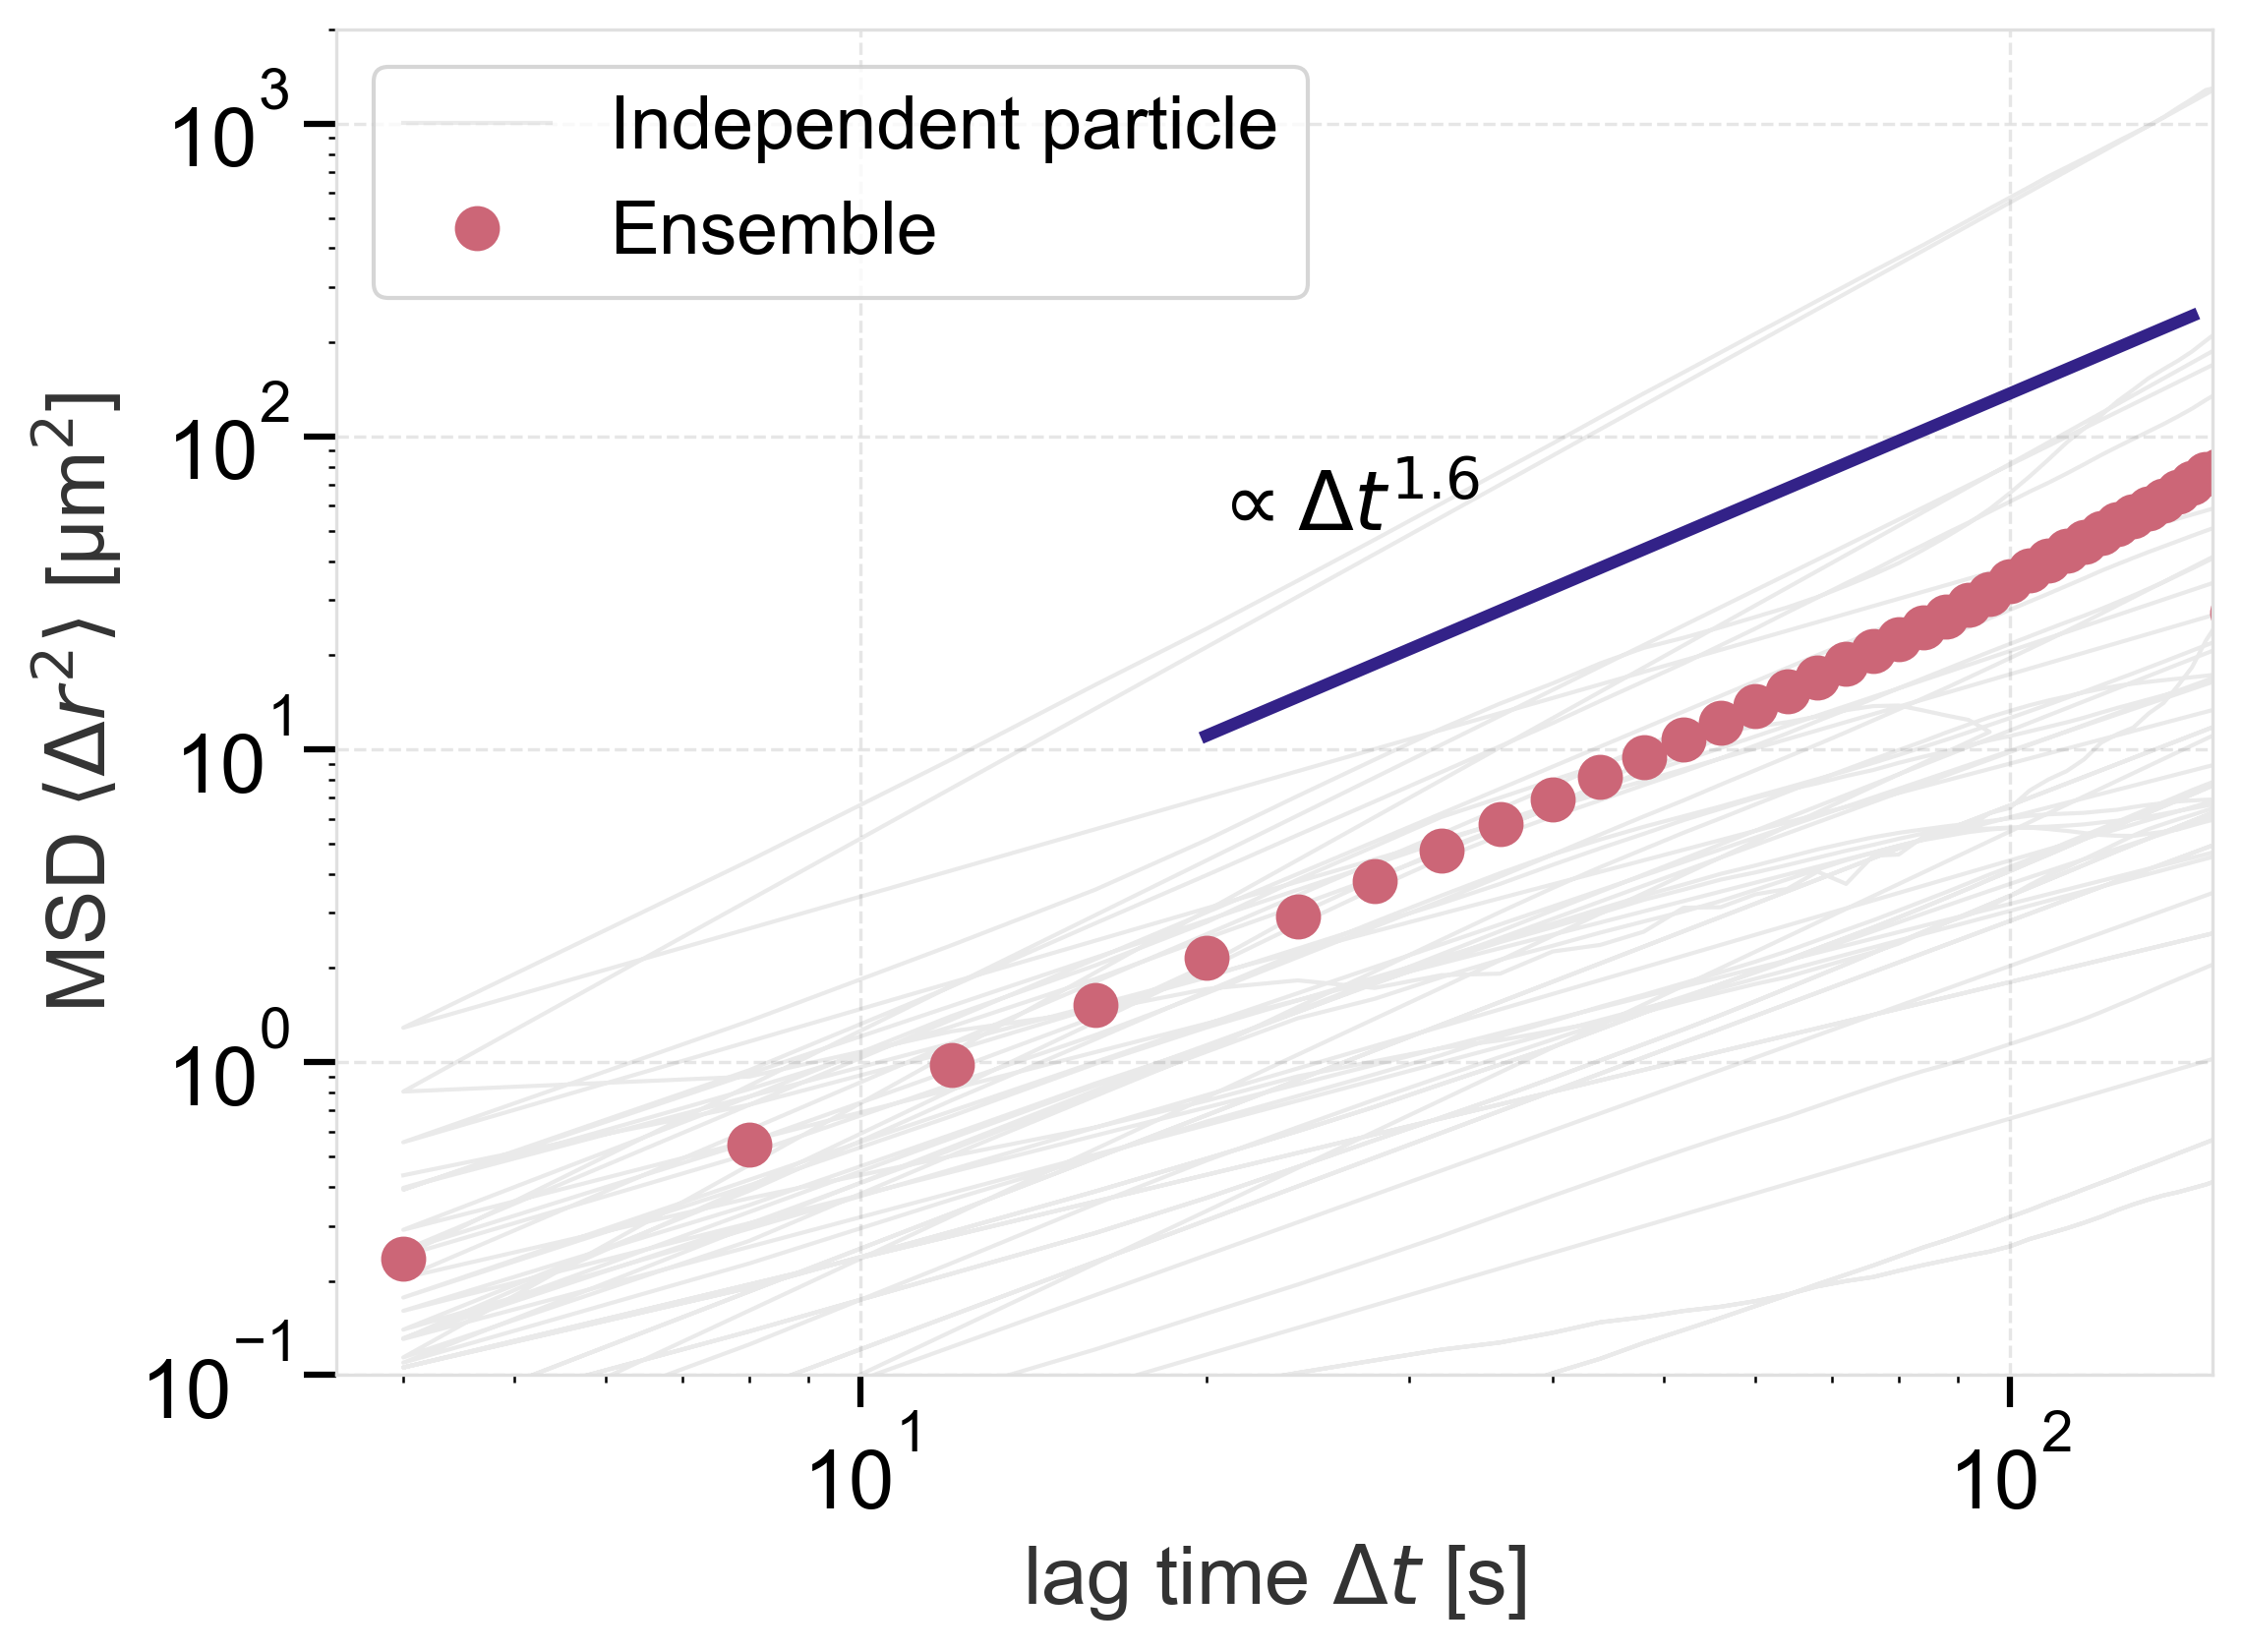

In [6]:
mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")


def concatMSD(path_list, interval_list, scale = 0.11):
    IMSD_list = []
    for i in range(len(path_list)):
        print(path_list[i])
        IMSD, _ = dpm.get_msd(path_list[i], scale, interval_list[i], threshold = 0.0)
        IMSD['particle'] += 10000*i
        IMSD_list.append(IMSD)

    return pd.concat(IMSD_list)

I_concat = concatMSD([path0, path1, path2, path4, path4], [ 4, 4, 4, 4, 4])

scale = 0.11

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined, emsd_err_combined = dpm.get_emsd_err(I_concat)

mask = (emsd_combined.index > minimum) & (emsd_combined.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined['MSD'][mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

ax.plot(I_concat['lag time'], I_concat['MSD'], color='#333333', alpha =0.1, lw=1, label='Independent particle')

ax.plot(emsd_combined.index, emsd_combined['MSD'], linestyle = 'None', marker='o', label='Ensemble')
"""ax.fill_between(emsd_combined.index,
                emsd_combined['MSD'] - emsd_err_combined,
                emsd_combined['MSD'] + emsd_err_combined,
                alpha=0.2)
"""

ax.legend()

xrange = [min_t, max_t]

ax.plot(xrange, fm.power_law(xrange, *popt) * 5, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$')
ax.text(20, 5e1, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')



ax.set(
    xlim=(3.5e-0, 150),
    ylim=(1e-1, 2e3),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
    )

cd = os.getcwd()
fig.savefig(f"{cd}/figures/MSD.png", bbox_inches = 'tight')
fig.savefig(f"{cd}/figures/MSD.pdf", bbox_inches = 'tight')


/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


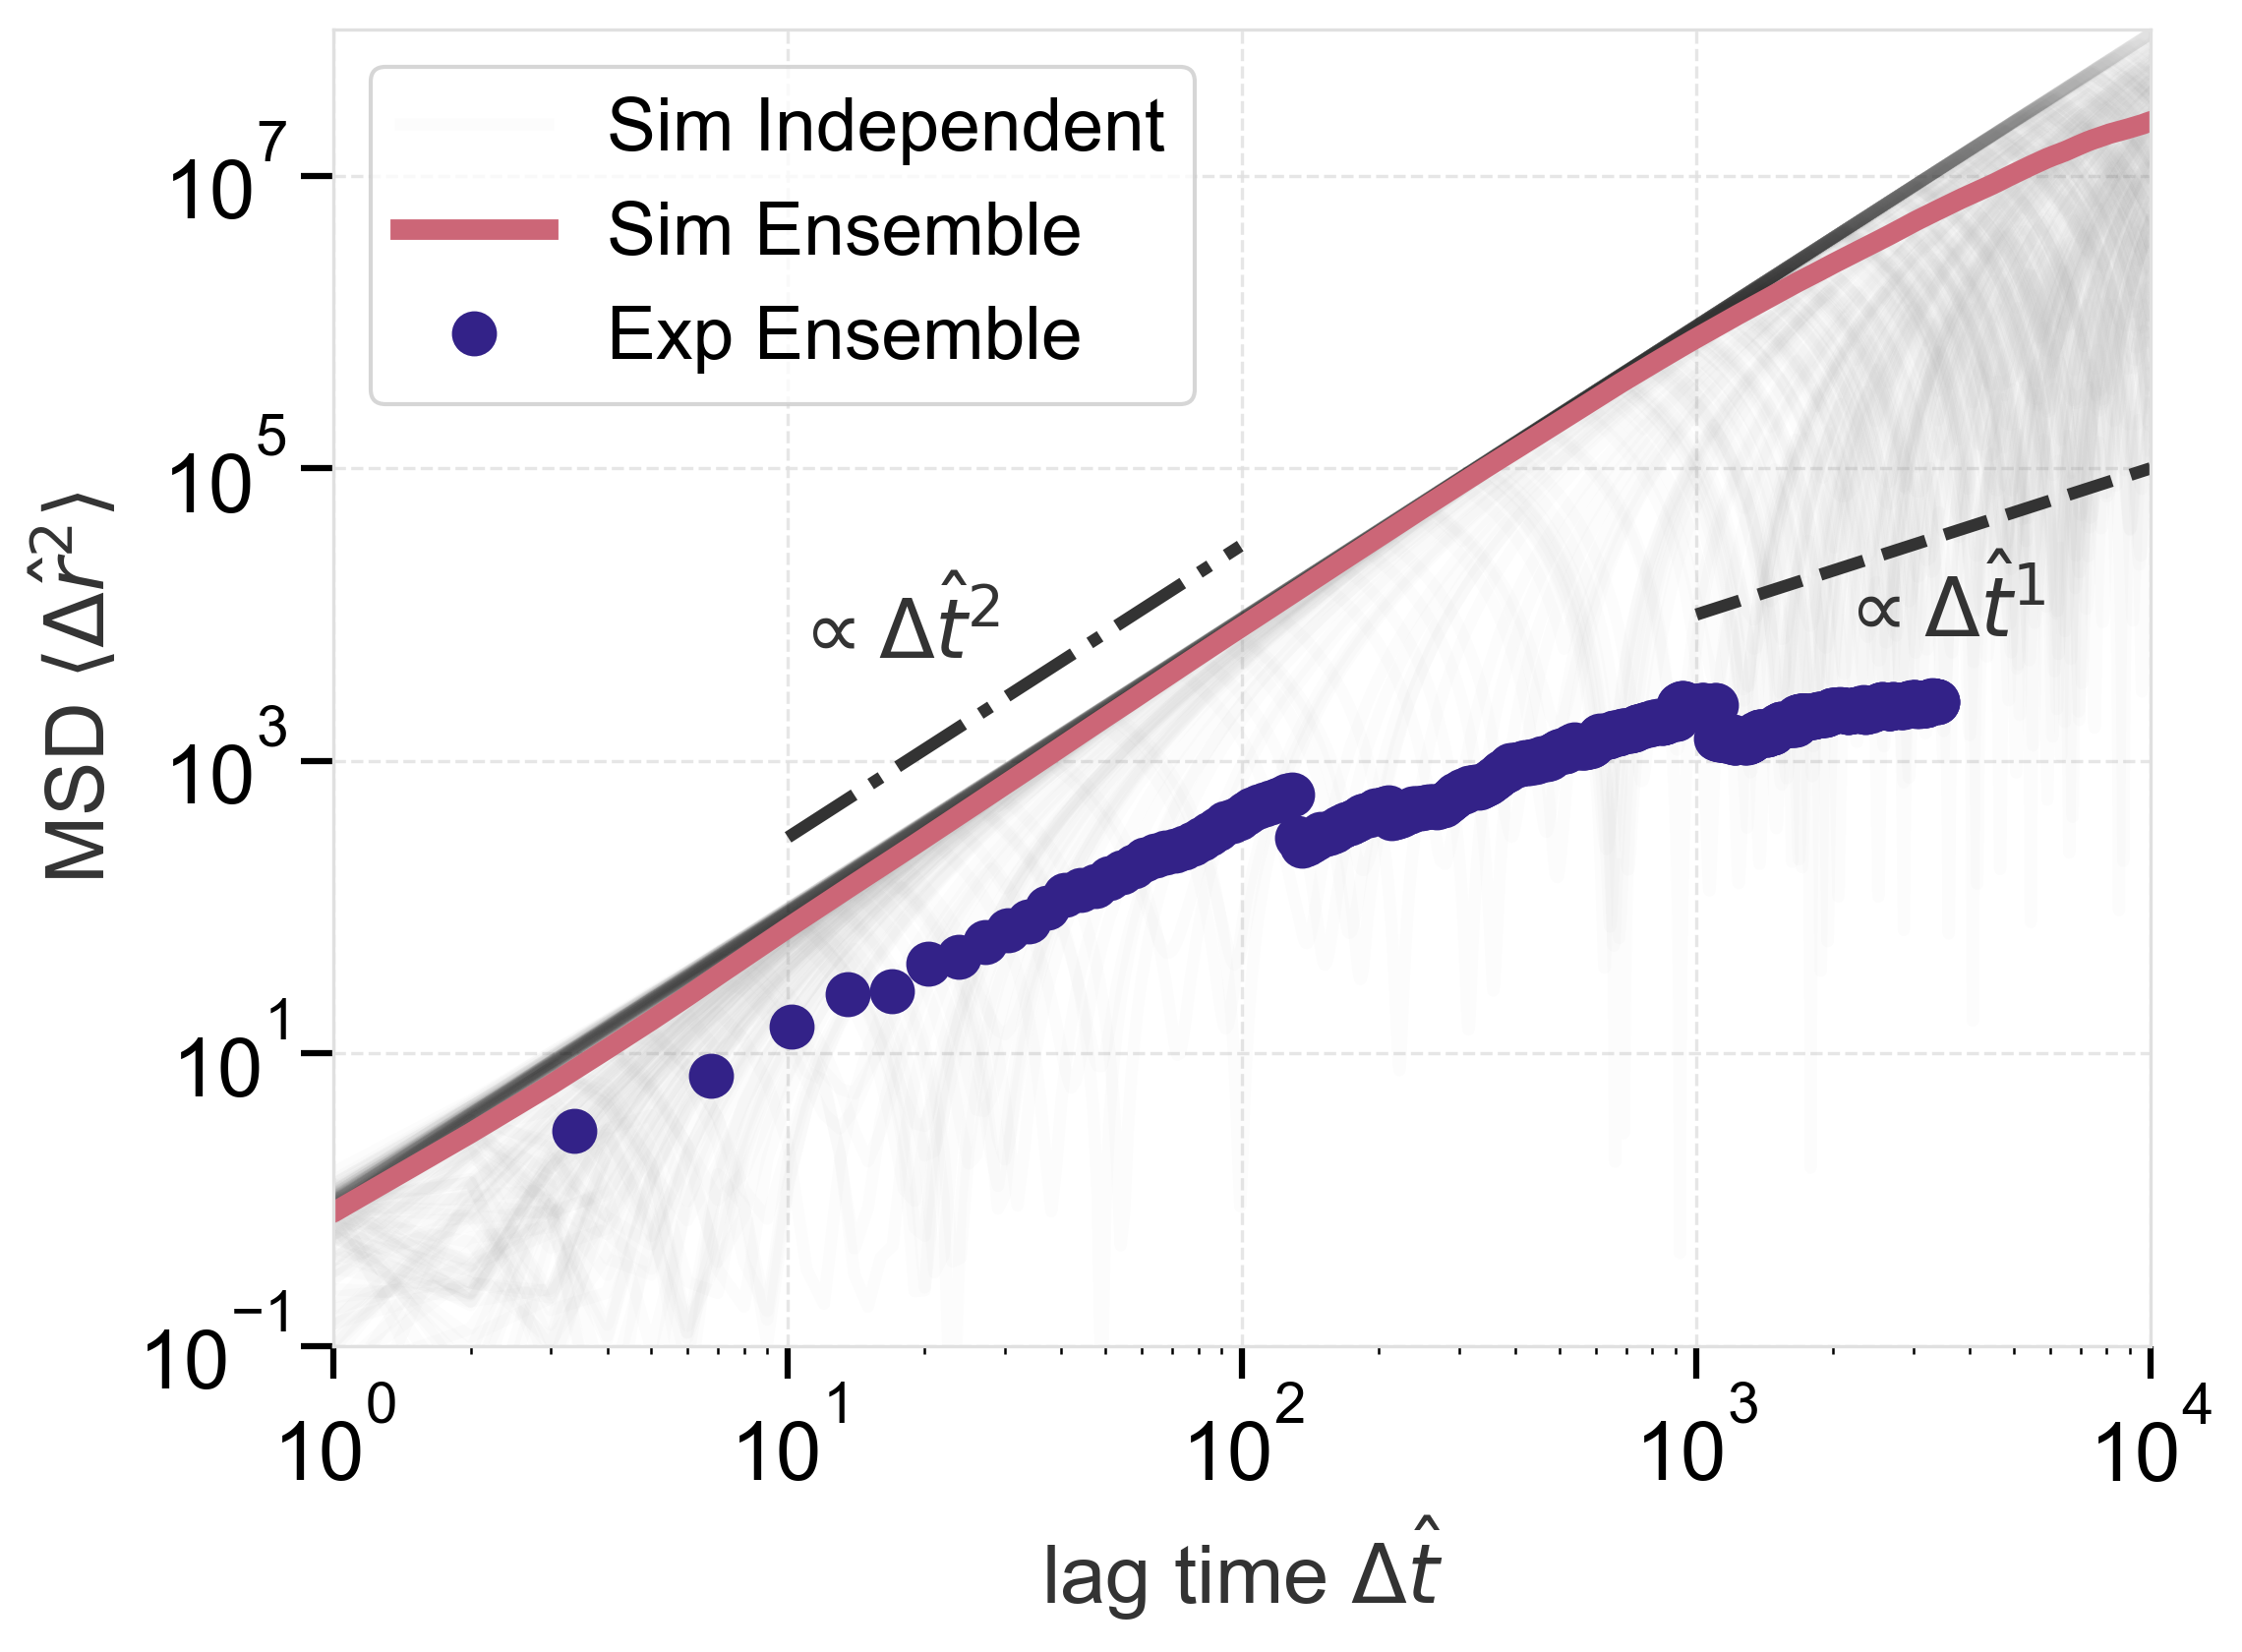

In [17]:
import zarr

mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")

zarr_path = r"/Users/sasakinozomu/code/MTCargoSim/analysis/data/cargo_msd_seeds.zarr"
data = zarr.open_array(zarr_path, mode='r')
leng = data.shape[1]
t = np.arange(leng)


def concatMSD(path_list, interval_list, scale = 0.11, time_averaged = True):
    IMSD_list = []
    for i in range(len(path_list)):
        print(path_list[i])
        IMSD, _ = dpm.get_msd(path_list[i], scale, interval_list[i], threshold = 0.0, time_averaged=time_averaged)
        IMSD['particle'] += 10000*i
        IMSD_list.append(IMSD)

    return pd.concat(IMSD_list)


I_concat = concatMSD([path0, path1, path2, path4, path4], [4, 4, 4, 4, 4], time_averaged=False)

scale = 0.11

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined, emsd_err_combined = dpm.get_emsd_err(I_concat)

mask = (emsd_combined.index > minimum) & (emsd_combined.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined['MSD'][mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

ax.plot(t, data[0, :], alpha=0.01, color="#333333", label="Sim Independent")
for i in range(1, data.shape[0]):
    ax.plot(t, data[i, :], alpha=0.01, color="#333333")

ax.plot(t, np.mean(data, axis=0), label='Sim Ensemble', lw=5)
ax.plot(emsd_combined.index/1.18, emsd_combined['MSD']/(0.59**2), linestyle = 'None', marker='o', label='Exp Ensemble', color = style_colors[1])

t1 = np.arange(1e3, 1e4)
t2 = np.arange(1e1, 1e2)

y1 = 1.0e1 * t1 ** 1.0
y2 = 3.0e-0 * t2 ** 2.0

ax.plot(t1, y1, c = '#333333', linestyle = '--')
ax.plot(t2, y2, c = '#333333', linestyle = '-.')

ax.text(2e3, 7e3, r'$\propto \Delta \hat{t}^{1}$', color='#333333')
ax.text(1e1, 5e3, r'$\propto \Delta \hat{t}^{2}$', color='#333333')

ax.legend()

xrange = [min_t, max_t]

#ax.plot(xrange, fm.power_law(xrange, *popt) * 5, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color = style_colors[0])

# ax.text(20, 5e1, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')

ax.set(
    xlim=(1e0, 1e4),
    ylim=(1e-1, 1e8),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta \hat{t}$',
    ylabel='MSD $\\langle \\Delta \\hat{r}^2 \\rangle$'
    )

cd = os.getcwd()
fig.savefig(f"{cd}/figures/exp_sim_MSD.png", bbox_inches = 'tight')
fig.savefig(f"{cd}/figures/exp_sim_MSD.pdf", bbox_inches = 'tight')
